In [1]:
import gymnasium as gym
from sumo_rl import SumoEnvironment

In [2]:
import os
import sys

os.environ["SUMO_HOME"] = r"C:\Program Files (x86)\Eclipse\Sumo"
sys.path.append(r"C:\Program Files (x86)\Eclipse\Sumo\tools")

# Verifica que funciona
import sumolib
print("✅ SUMO encontrado:", sumolib.checkBinary("sumo"))

✅ SUMO encontrado: C:\Program Files (x86)\Eclipse\Sumo\bin\sumo.exe


In [3]:
import os

NET = os.path.join("..", "..", "Simple_Intersection.net.xml")
ROU = os.path.join("..", "..", "Distribuciones", "Dist_Weibull_V2", "loja_intersection_weibull.rou.xml")

# Verifica que existen
print("¿net existe?", os.path.exists(NET))
print("¿rou existe?", os.path.exists(ROU))

¿net existe? True
¿rou existe? True


In [4]:
import os
import math
from sumo_rl import SumoEnvironment

# Crear la carpeta, antes de que SumoEnvironment la busque
os.makedirs('resultados_baseline', exist_ok=True)

# Inicializar el entorno
env = SumoEnvironment(
    net_file=NET,            # Asegúrate de que el nombre coincida
    route_file=ROU,  # Tu demanda de estrés (Hora Pico)
    out_csv_name='resultados_baseline/tiempo_fijo_weibull', # Nombre base para el reporte
    single_agent=True,
    use_gui=False,
    num_seconds=3652,
    fixed_ts=True
)

# Definir y ejecutar la simulación
def run_baseline():
    obs, info = env.reset()
    done = False
    
    print("Iniciando simulación de Tiempo Fijo (Baseline)...")
    
    tiempo_verde_fijo = 45  # 45 segundos de tiempo en semáforo en verde
    num_fases = env.action_space.n
    
    while not done:
        tiempo_simulacion = env.sim_step 
        
        # Rotar la fase del semáforo cada 45 segundos
        fase_actual = math.floor(tiempo_simulacion / tiempo_verde_fijo) % num_fases
        
        obs, reward, terminated, truncated, info = env.step(fase_actual)
        done = terminated or truncated
    
    # Cierra SUMO y fuerza la escritura del archivo CSV en el disco
    env.save_csv('resultados_baseline/tiempo_fijo_weibull', 1)
    env.close()
    print("✅ Simulación finalizada.")

# Llamada directa en Jupyter
run_baseline()

Iniciando simulación de Tiempo Fijo (Baseline)...
✅ Simulación finalizada.


Pasos simulados: 733
   step  system_total_stopped  system_total_waiting_time  \
0   0.0                     0                        0.0   
1   5.0                     0                        0.0   
2  10.0                     0                        0.0   
3  15.0                     0                        0.0   
4  20.0                     0                        0.0   

   system_mean_waiting_time  system_mean_speed  J11_stopped  \
0                       0.0                0.0            0   
1                       0.0                0.0            0   
2                       0.0                0.0            0   
3                       0.0                0.0            0   
4                       0.0                0.0            0   

   J11_accumulated_waiting_time  J11_average_speed  agents_total_stopped  \
0                           0.0                1.0                     0   
1                           0.0                1.0                     0   
2          

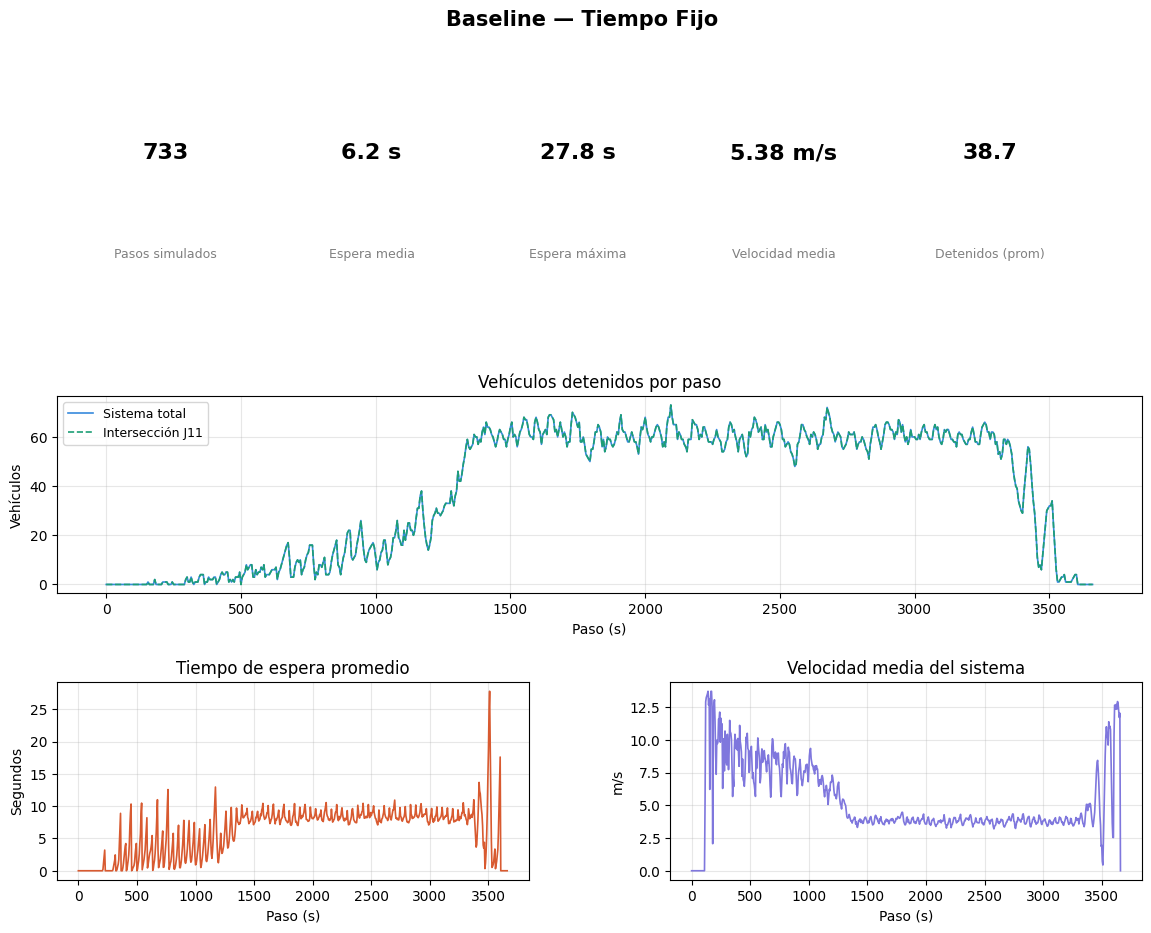

✅ Gráfico guardado en resultados_baseline/


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Carga el CSV ──────────────────────────────────────────────
df = pd.read_csv(".\\resultados_baseline\\tiempo_fijo_weibull_conn2_ep1.csv")

print(f"Pasos simulados: {len(df)}")
print(df.head())

# ── Dashboard ─────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
fig.suptitle("Baseline — Tiempo Fijo", fontsize=15, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

# Tarjetas de resumen
ax_info = fig.add_subplot(gs[0, :])
ax_info.axis("off")
metricas = {
    "Pasos simulados":   f"{len(df):,}",
    "Espera media":      f"{df['system_mean_waiting_time'].mean():.1f} s",
    "Espera máxima":     f"{df['system_mean_waiting_time'].max():.1f} s",
    "Velocidad media":   f"{df['system_mean_speed'].mean():.2f} m/s",
    "Detenidos (prom)":  f"{df['system_total_stopped'].mean():.1f}",
}
for i, (label, valor) in enumerate(metricas.items()):
    x = 0.1 + i * 0.19
    ax_info.text(x, 0.75, valor, transform=ax_info.transAxes,
                 fontsize=16, fontweight="bold", ha="center")
    ax_info.text(x, 0.25, label, transform=ax_info.transAxes,
                 fontsize=9, color="gray", ha="center")

# Vehículos detenidos
ax1 = fig.add_subplot(gs[1, :])
ax1.plot(df["step"], df["system_total_stopped"], color="#378ADD", linewidth=1.2, label="Sistema total")
ax1.plot(df["step"], df["J11_stopped"],          color="#1D9E75", linewidth=1.2, linestyle="--", label="Intersección J11")
ax1.set_title("Vehículos detenidos por paso")
ax1.set_xlabel("Paso (s)")
ax1.set_ylabel("Vehículos")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Tiempo de espera
ax2 = fig.add_subplot(gs[2, 0])
ax2.plot(df["step"], df["system_mean_waiting_time"], color="#D85A30", linewidth=1.2)
ax2.set_title("Tiempo de espera promedio")
ax2.set_xlabel("Paso (s)")
ax2.set_ylabel("Segundos")
ax2.grid(alpha=0.3)

# Velocidad media
ax3 = fig.add_subplot(gs[2, 1])
ax3.plot(df["step"], df["system_mean_speed"], color="#7F77DD", linewidth=1.2)
ax3.set_title("Velocidad media del sistema")
ax3.set_xlabel("Paso (s)")
ax3.set_ylabel("m/s")
ax3.grid(alpha=0.3)

plt.savefig(".\\resultados_baseline\\dashboard_baseline.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico guardado en resultados_baseline/")

In [6]:
print(f"Espera total acumulada (sistema): {df['system_total_waiting_time'].max():.1f} s")
print(f"Espera total acumulada (sistema): {df['system_total_waiting_time'].sum():.1f} s")
print(f"Vehículos detenidos pico:         {df['system_total_stopped'].max()}")
print(f"Vehículos detenidos promedio:     {df['system_total_stopped'].mean():.1f}")

Espera total acumulada (sistema): 1433.0 s
Espera total acumulada (sistema): 509011.0 s
Vehículos detenidos pico:         73
Vehículos detenidos promedio:     38.7
